# Analyze and plot the results of linear treadmill with reward simulation

### Import

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

In [2]:
scenario = "linear_shock"
trial_number = 10
save_plot = False

In [3]:
base_path = os.path.sep.join(os.path.abspath("__file__").split(os.path.sep)[:-2])
data_path = os.path.join(base_path,"data",scenario)
plot_path = os.path.join(base_path,"results",scenario,"plots")
folder_root = "trial"

sys.path.insert(0, os.path.join(base_path,"code/functions"))
os.makedirs(plot_path, exist_ok=True)

target_seed = np.arange(trial_number)

# Add the directory to sys.path
ref_path = os.path.join(data_path,folder_root+str(target_seed[0]))
sys.path.append(ref_path)

from global_variables import *
from linear_shock_variables import *
from linear_shock_functions import *
from plots import *
from stat_functions import *


# Fig. 6, Aversive stimuli learning 

### Fig. 6c, Perceived salience

In [4]:
target_lap = np.arange(4)+1; feat_lap = 4
feat_state = num_state_total-1; feat_ID = 1
feat_speed = feature_speed[feat_ID]

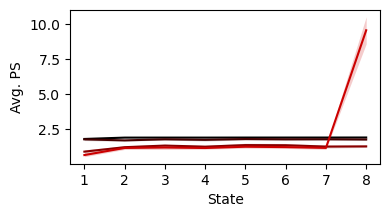

In [5]:
windows_per_state = steps_per_unit*np.ones((len(target_lap),num_state_total),dtype=int)
windows_per_state[target_lap==feat_lap,feat_state] = int(steps_per_unit/feat_speed)

windows_per_state = np.cumsum(windows_per_state,axis=1)
windows_per_state = np.hstack((np.zeros((len(target_lap),1),dtype=int),windows_per_state))

PS_arr = list()
mean_PS = np.zeros((len(target_lap),num_state_total,len(target_seed)))

for jj, seed in enumerate(target_seed):
    foldername = folder_root + str(seed)
    for ee, load_lap in enumerate(target_lap):
        PS_lap = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%(load_lap)))["PS_list"]
        PS_arr.append(PS_lap)
        
        for ss in range(num_state_total):
            if np.any(np.isnan(PS_lap)): print(PS_lap[np.isnan(PS_lap)])
            mean_PS[ee,ss,jj] = np.mean(PS_lap[windows_per_state[ee,ss]:windows_per_state[ee,ss+1]])

        del PS_lap

colors = create_gradient([0,0,0],[0.8,0,0],len(target_lap))
fig, ax = plt.subplots(1,1,figsize=(4,2))
for ii, ee in enumerate(target_lap):
    plot_shaded(np.arange(num_state_total)+1, mean_PS.mean(-1)[ii], mean_PS.std(-1)[ii], ax=ax, color=colors[ii])

ax.set_xticks(np.arange(num_state_total)+1); ax.set_xlabel("State"); ax.set_ylabel("Avg. PS")
if save_plot: plt.savefig(os.path.join(plot_path,"Average_PS.png"), dpi=300)
plt.show()

In [6]:
# Fig. 6c — Paired t-test: PS at shock state vs. mean of non-shock states
# Each seed contributes both values, so the comparison is paired (per-seed difference).

non_shock_states = np.setdiff1d(np.arange(num_state_total), [feat_state])
non_feat_lap     = np.setdiff1d(np.arange(len(target_lap)), [feat_lap - 1])

# ---- Laps 1–3 (familiarization): per-seed average over the non-feature laps ----
ps_shock      = np.zeros((len(non_feat_lap), len(target_seed)))
ps_nonsalient = np.zeros((len(non_feat_lap), len(target_seed)))
for k, lap in enumerate(non_feat_lap):
    ps_shock[k]      = mean_PS[lap, feat_state, :]                    # (n_seeds,)
    ps_nonsalient[k] = mean_PS[lap, non_shock_states, :].mean(axis=0) # (n_seeds,)
ps_shock      = ps_shock.mean(0)        # (n_seeds,) per-seed mean over laps 1–3
ps_nonsalient = ps_nonsalient.mean(0)   # (n_seeds,)

t_stat, p_val = stats.ttest_rel(ps_shock, ps_nonsalient)
d_z          = cohens_d_paired(ps_shock, ps_nonsalient)
ci_lo, ci_hi = ci_paired(ps_shock, ps_nonsalient)
print(f"Fig. 6c — PS shock (state {feat_state+1}) vs. non-salient (mean), laps 1–{feat_lap-1} average:")
print(f"  t={t_stat:.3f}, p={p_val:.4g}, d_z={d_z:.3f}, 95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")
del ps_shock, ps_nonsalient

# ---- Lap 4 (shock) ----
ps_shock      = mean_PS[feat_lap - 1, feat_state, :]                    # (n_seeds,)
ps_nonsalient = mean_PS[feat_lap - 1, non_shock_states, :].mean(axis=0) # (n_seeds,)

t_stat, p_val = stats.ttest_rel(ps_shock, ps_nonsalient)
d_z          = cohens_d_paired(ps_shock, ps_nonsalient)
ci_lo, ci_hi = ci_paired(ps_shock, ps_nonsalient)
print(f"Fig. 6c — PS shock (state {feat_state+1}) vs. non-salient (mean), lap {feat_lap}:")
print(f"  t={t_stat:.3f}, p={p_val:.4g}, d_z={d_z:.3f}, 95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")

Fig. 6c — PS shock (state 8) vs. non-salient (mean), laps 1–3 average:
  t=1.242, p=0.2455, d_z=0.393, 95% CI [-0.0144, 0.0496]
Fig. 6c — PS shock (state 8) vs. non-salient (mean), lap 4:
  t=26.457, p=7.608e-10, d_z=8.367, 95% CI [7.7128, 9.1551]


In [7]:
# Fig. 6c — Paired t-test: PS at shock state vs. mean of non-shock states
# Each seed contributes both values, so the comparison is paired (per-seed difference).

def p_to_stars(p):
    if p < 1e-4:  return "****"
    if p < 1e-3:  return "***"
    if p < 1e-2:  return "**"
    if p < 5e-2:  return "*"
    return ""

def fmt_p(p):
    """Format a p-value for LaTeX: scientific notation if small, else 2 decimals."""
    if p < 1e-2:
        mant, exp = f"{p:.2e}".split("e")
        return rf"{float(mant):.2f}\times10^{{{int(exp)}}}"
    return f"{p:.2f}"

def fmt_line(p_adj, dz, ci):
    stars = p_to_stars(p_adj)
    pstr  = fmt_p(p_adj)
    ns    = "" if stars else r" (n.s.)"
    return (rf"{stars}$P_{{\mathrm{{adj}}}} = {pstr}${ns}, "
            rf"$d_z = {dz:.2f}$, 95\% CI $[{ci[0]:.2f}, {ci[1]:.2f}]$")

non_shock_states = np.setdiff1d(np.arange(num_state_total), [feat_state])
non_feat_lap     = np.setdiff1d(np.arange(len(target_lap)), [feat_lap - 1])

# ---- Laps 1–3 (familiarization): per-seed average over the non-feature laps ----
ps_shock      = np.zeros((len(non_feat_lap), len(target_seed)))
ps_nonsalient = np.zeros((len(non_feat_lap), len(target_seed)))
for k, lap in enumerate(non_feat_lap):
    ps_shock[k]      = mean_PS[lap, feat_state, :]
    ps_nonsalient[k] = mean_PS[lap, non_shock_states, :].mean(axis=0)
ps_shock      = ps_shock.mean(0)
ps_nonsalient = ps_nonsalient.mean(0)

_, p13     = stats.ttest_rel(ps_shock, ps_nonsalient)
dz13       = cohens_d_paired(ps_shock, ps_nonsalient)
ci13       = ci_paired(ps_shock, ps_nonsalient)
del ps_shock, ps_nonsalient

# ---- Lap 4 (shock) ----
ps_shock      = mean_PS[feat_lap - 1, feat_state, :]
ps_nonsalient = mean_PS[feat_lap - 1, non_shock_states, :].mean(axis=0)

_, p4      = stats.ttest_rel(ps_shock, ps_nonsalient)
dz4        = cohens_d_paired(ps_shock, ps_nonsalient)
ci4        = ci_paired(ps_shock, ps_nonsalient)

# ---- BH-FDR across the two tests in this panel ----
_, p_adj, _, _ = multipletests([p13, p4], method='fdr_bh')
p13_adj, p4_adj = p_adj

# ---- LaTeX caption line ----
caption_c = (
    r"\textbf{c}, PS experienced at each state on laps 1--4. "
    r"Paired $t$-tests, $N_{\mathrm{seed}}=10$: "
    rf"laps 1--3 (per-seed average), PS at state {feat_state+1} vs.\ the remaining states, "
    rf"{fmt_line(p13_adj, dz13, ci13)}; "
    rf"lap {feat_lap}, PS at state {feat_state+1} vs.\ the remaining states, "
    rf"{fmt_line(p4_adj, dz4, ci4)}."
)
print(caption_c)

\textbf{c}, PS experienced at each state on laps 1--4. Paired $t$-tests, $N_{\mathrm{seed}}=10$: laps 1--3 (per-seed average), PS at state 8 vs.\ the remaining states, $P_{\mathrm{adj}} = 0.25$ (n.s.), $d_z = 0.39$, 95\% CI $[-0.01, 0.05]$; lap 4, PS at state 8 vs.\ the remaining states, ****$P_{\mathrm{adj}} = 1.52\times10^{-9}$, $d_z = 8.37$, 95\% CI $[7.71, 9.16]$.


### Fig. 6d, Emergence of place cells

In [8]:
load_lap = 4
seed = target_seed[0]
foldername = folder_root + str(seed)

CA1_activity = np.load(os.path.join(data_path, foldername, "activity/CA1_activity_lap_"+str(load_lap)+".npz"))["CA1_activity"]
CA1_PF = load_PF_starts(os.path.join(data_path, foldername, "detected_PC/CA1_lap_"+str(load_lap)+".pkl"))

place_field_sorted_idx = np.array(list(CA1_PF.keys()))
place_div_idx = np.hstack((place_field_sorted_idx,np.setdiff1d(np.arange(num_CA1_neurons),place_field_sorted_idx)))

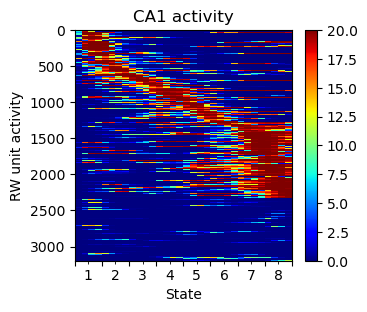

In [9]:
xlab = []

for ii in range(num_state_total):
    xlab.append("%d"%(ii))

data = CA1_activity[:, place_div_idx].T
x = np.arange(data.shape[1] + 1)
y = np.arange(data.shape[0] + 1)

#place_field_sorted_idx
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3))
fig, ax = plot_heatmap(data, fig, ax, title="CA1 activity", cmap="jet", vmin=0, vmax=max_input_FR)
plt.gca().yaxis.set_inverted(True)
ax.set_xlabel("State"); ax.set_ylabel("Neuron"); ax.set_xticklabels([])
x_ticks = np.linspace(0,int(unit_gran)*num_state_total,num_state_total+1)
ax.set_xticks(x_ticks); ax.set_xticklabels([])
ax.set_xticks(x_ticks[:-1]+unit_gran/2, minor=True)
ax.set_xticklabels(np.array(np.arange(num_state_total)+1,dtype=str), minor=True)
ax.set_ylabel("RW unit activity"); ax.set_xlabel("State")

if save_plot: plt.savefig(os.path.join(plot_path,"CA1_activity_lap_%d.png"%(load_lap)), dpi=300)
plt.show()

### Fig. 6e, Place fields change after the introduction of shock

In [10]:
target_lap = [3, 4]
PC_count = np.zeros((len(target_seed), len(target_lap), num_state_total))

for ii, seed in enumerate(target_seed):
    foldername = folder_root + str(seed)
    for ee, lap in enumerate(target_lap):
        CA1_PF = load_PF_starts(
            os.path.join(data_path, foldername, "detected_PC/CA1_lap_%d.pkl" % lap)
        )
        counts = np.zeros(num_state_total, dtype=int)
        for nid, pos in CA1_PF.items():
            state = int(pos[1])  # pos[1] = s + 0.5 → int gives state index
            if 0 <= state < num_state_total:
                counts[state] += 1
        total = counts.sum()
        if total > 0:
            PC_count[ii, ee, :] = counts / total  # fraction per state

print(f"PC_count shape: {PC_count.shape}")  # (n_trials, n_laps, n_states)
print(f"Laps: {target_lap}")
print(f"Mean fraction per state (lap {target_lap[0]}): {PC_count[:,0,:].mean(0).round(3)}")

PC_count shape: (10, 2, 8)
Laps: [3, 4]
Mean fraction per state (lap 3): [0.164 0.113 0.097 0.126 0.114 0.101 0.093 0.193]


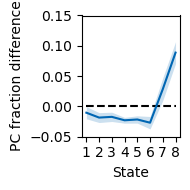

In [11]:
fig, ax = plt.subplots(1,1,figsize=(2,2))
plt.plot(np.arange(num_state_total)+1,np.zeros(num_state_total),'--',color='k')
PC_diff = PC_count[:,1] - PC_count[:,0]
plot_shaded(np.arange(num_state_total)+1, PC_diff.mean(0), PC_diff.std(0), ax=ax, color=[0,0.4,0.7])
ax.set_yticks(np.arange(-0.05,0.16,0.05)); ax.set_ylabel("PC fraction difference")
ax.set_xticks(np.arange(num_state_total)+1); ax.set_xlabel("State")

plt.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path, "PC_proportion_development.png"), dpi=300)
plt.show()

In [12]:
pc_pvals = [stats.ttest_1samp(PC_diff[:, ss], 0, alternative='greater')[1]
            for ss in range(num_state_total)]
_, pc_pfdr, _, _ = multipletests(pc_pvals, method='fdr_bh')

for ss, p, p_q in zip(range(num_state_total), pc_pvals, pc_pfdr):
    x = PC_diff[:, ss]
    d = cohens_d_1samp(x, 0)
    ci_lo, ci_hi = ci_1samp(x)
    print(f"PC proportion increment before -> after shock > 0, state {ss+1}: p={p:.4g}, p_fdr={p_q:.4g}, "
          f"d={d:.3f}, 95% CI [{ci_lo:.4f}, {ci_hi:.4f}]")

PC proportion increment before -> after shock > 0, state 1: p=0.9935, p_fdr=1, d=-0.977, 95% CI [-0.0180, -0.0028]
PC proportion increment before -> after shock > 0, state 2: p=1, p_fdr=1, d=-2.140, 95% CI [-0.0246, -0.0123]
PC proportion increment before -> after shock > 0, state 3: p=1, p_fdr=1, d=-2.128, 95% CI [-0.0230, -0.0114]
PC proportion increment before -> after shock > 0, state 4: p=1, p_fdr=1, d=-4.541, 95% CI [-0.0265, -0.0193]
PC proportion increment before -> after shock > 0, state 5: p=1, p_fdr=1, d=-3.379, 95% CI [-0.0261, -0.0170]
PC proportion increment before -> after shock > 0, state 6: p=1, p_fdr=1, d=-2.481, 95% CI [-0.0346, -0.0191]
PC proportion increment before -> after shock > 0, state 7: p=0.0006637, p_fdr=0.002655, d=1.448, 95% CI [0.0145, 0.0427]
PC proportion increment before -> after shock > 0, state 8: p=6.179e-08, p_fdr=4.943e-07, d=4.694, 95% CI [0.0752, 0.1023]


### Fig. 6g, Spontaneous off-site offline activity

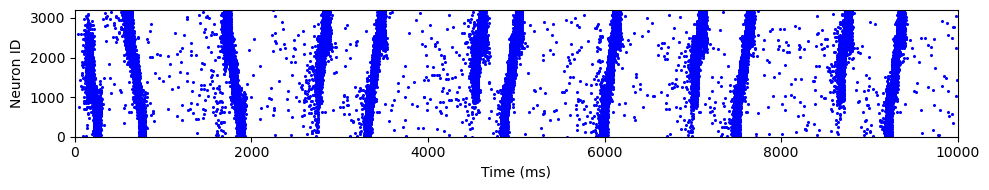

In [13]:
example_seed = target_seed[7]; load_lap = 4

CA3_PF = load_PF_starts()
CA3_place_cell_ID_list = generate_place_cell_ID_list(np.array(list(CA3_PF.keys()),dtype=int), np.array(list(CA3_PF.values())))
target_idx = reorder_neuron_idx(CA3_place_cell_ID_list,CA3_PF,np.arange(num_state_col))

ff = np.load(os.path.join(data_path,folder_root+str(example_seed),"CA3_replay_lap_%d.npz"%(load_lap)))
spike_times_CA3_PC = ff['spike_times_CA3_PC']; spiking_neurons_CA3_PC = ff['spiking_neurons_CA3_PC']; rate_CA3_PC = ff['rate_CA3_PC']
del ff

fig, ax = plt.subplots(1,1,figsize=(10,2))
plot_spike(spike_times_CA3_PC, spiking_neurons_CA3_PC, target_idx, zoom_to=rest_time, ax=ax)
ax.set_ylim([0, num_CA3_neurons])

fig.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path,"Spontaneous_offsite_activity_lap_%d.png"%(load_lap)), dpi=300)
plt.show()

### Fig. 6h, Predicted presence of shock at each state

In [14]:
replay_lap = 4
unit_gran = np.load(os.path.join(data_path,foldername,"activity/CA1_activity_lap_%d.npz"%replay_lap))["unit_gran"]
feat_pred = np.zeros((len(target_seed),len(target_lap),num_state_total,num_features))
feat_pred_replay = np.zeros((len(target_seed),num_state_total,num_features))

In [15]:
for mm, seed in enumerate(target_seed):
    foldername = folder_root+str(seed)
    
    for ee, load_lap in enumerate(target_lap):
        w_CA1_feat = 10*np.load(os.path.join(data_path,foldername,"lap_%d.npz"%(load_lap)))["w_CA1_feat"]
        CA1_activity = np.load(os.path.join(data_path,foldername,"activity/CA1_activity_lap_%d.npz"%(load_lap)))["CA1_activity"]
        feat_pred_temp = CA1_activity@w_CA1_feat
        for ss in range(num_state_total):
            feat_pred[mm,ee,ss] = np.mean(feat_pred_temp[ss*unit_gran:(ss+1)*unit_gran],axis=0)
        # del CA1_activity, feat_pred_temp

        if load_lap == replay_lap:
            CA1_rep_activity = np.load(os.path.join(data_path,foldername,"activity/CA1_lap_%d_0_9999_replayed.npz"%(load_lap)))["CA1_activity"]
            feat_pred_temp = (CA1_rep_activity@w_CA1_feat)
            for ss in range(num_state_total): 
                feat_pred_replay[mm,ss] = np.mean(feat_pred_temp[ss*unit_gran:(ss+1)*unit_gran],axis=0)
            # del w_CA1_feat, CA1_rep_activity, feat_pred_temp

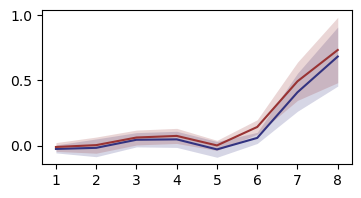

In [16]:
colorTheme = [[0,.7,.5],[.2,.2,.5],[.6,.2,.2]]

fig, ax = plt.subplots(1,1,figsize=(4, 2))

xx = np.arange(num_state_total)+1

ax = plot_shaded(xx, feat_pred[:,1,:,feat_ID].mean(0), feat_pred[:,1,:,feat_ID].std(0),color=colorTheme[1],ax=ax)
ax = plot_shaded(xx, feat_pred_replay[:,:,feat_ID].mean(0), feat_pred_replay[:,:,feat_ID].std(0),color=colorTheme[2],ax=ax)

ax.set_xticks(np.linspace(1,num_state_total,num_state_total))
ax.set_yticks(np.arange(-.0,1.1,.5))
if save_plot: plt.savefig(os.path.join(plot_path,"predicted_presence_shock.png"), dpi=300)
plt.show()

In [18]:
# Fig. 6g — Paired t-test: shock prediction before vs. after offline replay, per state (BH-FDR)
pre_pred  = feat_pred[:, 1, :, feat_ID]   # (n_seeds, num_state_total)
post_pred = feat_pred_replay[:, :, feat_ID]           # (n_seeds, num_state_total)

pvals_g = []
for ss in range(num_state_total):
    _, p = stats.ttest_rel(pre_pred[:, ss], post_pred[:, ss])
    pvals_g.append(p)
_, pfdr_g, _, _ = multipletests(pvals_g, method='fdr_bh')

print("Fig. 6g — Paired t-test pre vs. post offline (BH-FDR across states):")
# print(f"{'State':>6}  {'p':>10}  {'p_fdr':>10}  {'d_z':>8}  95% CI")
for ss in range(num_state_total):
    d   = cohens_d_paired(pre_pred[:, ss], post_pred[:, ss])
    ci_lo, ci_hi = ci_paired(pre_pred[:, ss], post_pred[:, ss])
    sig = '*' if pfdr_g[ss] < 0.05 else 'n.s.'
    print(f"  {ss+1:>4}  {pvals_g[ss]:>10.4g}  {pfdr_g[ss]:>10.3g}  {d:>8.3f}  "
          f"[{ci_lo:.4f}, {ci_hi:.4f}] {sig}")
    # print("state %d, %s$p_{adj}=%.2g$, d=%.2f, 95%% CI $[%.3f, %.3f]$;" % (ss+1, sig, pfdr_g[ss], d, ci_lo, ci_hi))

Fig. 6g — Paired t-test pre vs. post offline (BH-FDR across states):
     1     0.00289     0.00578    -1.280  [-0.0236, -0.0067] *
     2     0.05625      0.0562    -0.693  [-0.0422, 0.0007] n.s.
     3    0.001248     0.00333    -1.462  [-0.0257, -0.0088] *
     4     0.01331      0.0213    -0.971  [-0.0460, -0.0070] *
     5      0.0323      0.0404    -0.800  [-0.0575, -0.0032] *
     6   4.266e-06    3.41e-05    -3.096  [-0.1033, -0.0645] *
     7    0.001055     0.00333    -1.500  [-0.1241, -0.0439] *
     8     0.03537      0.0404    -0.782  [-0.0964, -0.0043] *


### Fig. 6i, Markov transition matrices before and after offline learning

In [20]:
# num_behav_trial = 100
total_time = 600
possible_actions = np.array([[0,-1],[0,0],[0,1]])  # left, stay, right

In [56]:
value_arr = np.zeros((len(target_seed),3,num_state_total))           
for mm in range(len(target_seed)):
    value_arr[mm,0] = feat_pred[mm,0]@value_vector
    value_arr[mm,1] = feat_pred[mm,1]@value_vector
    value_arr[mm,2] = feat_pred_replay[mm]@value_vector

transition_matrix = np.zeros((len(target_seed), value_arr.shape[-1], num_state_total, num_state_total))

for mm in range(len(target_seed)):
    for vv in range(value_arr.shape[1]):
        transition_matrix[mm,vv,:,:], _ = compute_transition_matrix(num_state_total,value_arr[mm,vv],possible_actions,end_state=[-1])


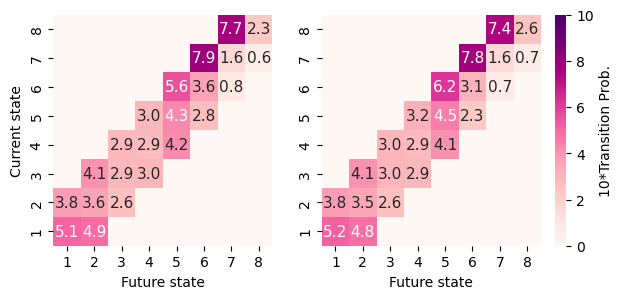

In [57]:
fig, axs = plt.subplots(1,2,width_ratios=(4,5),figsize=(7, 3))
annot_data = create_annot_nonzero(10*transition_matrix.mean(0)[1])
sns.heatmap(10*transition_matrix.mean(0)[1], annot=annot_data, fmt='', annot_kws={"size":11},cmap="RdPu",ax=axs[0],vmax=10,cbar=False)
axs[0].set_xticklabels(np.arange(1,num_state_total+1)); axs[0].set_yticklabels(np.arange(1,num_state_total+1))
axs[0].invert_yaxis(); axs[0].set_ylabel("Current state"); axs[0].set_xlabel("Future state")

annot_data = create_annot_nonzero(10*transition_matrix.mean(0)[2])
sns.heatmap(10*transition_matrix.mean(0)[2], annot=annot_data, fmt='', annot_kws={"size":11},cmap="RdPu",ax=axs[1],vmax=10,cbar_kws={'label': '10*Transition Prob.'})
axs[1].set_xticklabels(np.arange(1,num_state_total+1)); axs[1].set_yticklabels(np.arange(1,num_state_total+1))
axs[1].invert_yaxis(); axs[1].set_xlabel("Future state")

if save_plot: plt.savefig(os.path.join(plot_path,"transition_matrix.png"), dpi=300)
plt.show()


### Fig. 6j, Simulated behavioral phase

In [58]:
num_behav_trial = 100
init_seed = 12345

trajectory_arr = np.zeros((value_arr.shape[1],len(target_seed),total_time,num_behav_trial))
SZ_occupancy = np.zeros((value_arr.shape[1],len(target_seed),num_behav_trial))
SH_occupancy = np.zeros((value_arr.shape[1],len(target_seed),num_behav_trial))
for mm in range(len(target_seed)):
    for tt in range(num_behav_trial):
        for vv in range(value_arr.shape[1]):
            trajectory_arr[vv,mm,:,tt],_,_ = behavior_markov(transition_matrix[mm,vv], total_time=total_time, start_state=0, seed=init_seed+mm*100+tt*10)
            SZ_occupancy[vv,mm,tt] = np.sum(trajectory_arr[vv,mm,:,tt]==feat_state)/total_time
            SH_occupancy[vv,mm,tt] = np.sum((trajectory_arr[vv,mm,:,tt]>=num_state_total//2)&(trajectory_arr[vv,mm,:,tt]<=feat_state))/total_time


In [63]:
colors = [[0,.7,.5],[.2,.2,.5],[.6,.2,.2]]

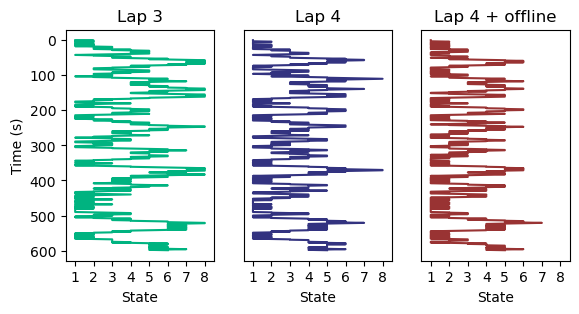

In [86]:
plot_tr = 3
load_seed = 0

fig, axs = plt.subplots(1,3,figsize=(6.5,3)); Titles = ["Lap 3","Lap 4","Lap 4 + offline"]
for xx in range(value_arr.shape[1]):
    axs[xx].plot(trajectory_arr[xx,load_seed,:,plot_tr]+1,np.arange(total_time),color=colors[xx]); axs[xx].set_xlim([.5,num_state_total+.5]); axs[xx].set_xticks(np.arange(1,num_state_total+1)); axs[xx].invert_yaxis()
    if xx>0: axs[xx].set_yticks([])
    else: axs[xx].set_ylabel("Time (s)")
    axs[xx].set_title(Titles[xx])
    axs[xx].set_xlabel("State")

if save_plot: plt.savefig(os.path.join(plot_path,"simulated_behavior.png"), dpi=300)
plt.show()

### Fig. 6k, Near-shock-zone occupancy

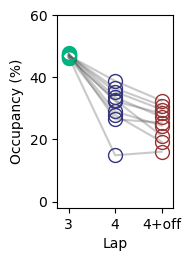

Fig. 6j — Near-shock occupancy, paired t-tests (BH-FDR across 3 pairs):
  No shock vs. Shock: *p_adj=4.75e-05, d_z=2.418, 95% CI [11.449, 21.067];
  Shock vs. Shock+offline: *p_adj=0.00117, d_z=1.477, 95% CI [2.716, 7.817];
  No shock vs. Shock+offline: *p_adj=9.38e-07, d_z=4.216, 95% CI [17.872, 25.177];


In [ ]:
np.squeeze(SH_occupancy)
plt.figure(figsize=(1.5, 2.5))
xx = np.arange(3)+1

for seed in range(len(target_seed)):
    data = SH_occupancy[:,seed,:].mean(-1)*100
    plt.plot(np.arange(3)+1, data, '-', color=[.3,.3,.3,.3])
    for cc in range(3):
        plt.plot([cc+1], data[cc], 'o', markersize = 10, markerfacecolor=(0,0,0,0), markeredgecolor=colors[cc])

plt.xlim([0.75,3.25]); plt.xticks([1,2,3],[]); plt.ylim([-2,60])
plt.xticks([1,2,3],['3','4','4+off']); plt.xlabel("Lap"); plt.ylabel("Occupancy (%)")
if save_plot: plt.savefig(os.path.join(plot_path,"near_shock_occupancy.png"), dpi=300)
plt.show()

# Fig. 6k — Paired t-tests: near-shock occupancy across conditions (per-seed means, BH-FDR)
occ_per_seed = SH_occupancy.mean(-1) * 100   # (3, n_seeds) — average over behavioral trials

pair_indices = [(0, 1), (1, 2), (0, 2)]
pair_labels  = ['No shock vs. Shock', 'Shock vs. Shock+offline', 'No shock vs. Shock+offline']

pvals_j = []
for i, j in pair_indices:
    _, p = stats.ttest_rel(occ_per_seed[i], occ_per_seed[j])
    pvals_j.append(p)
_, pfdr_j, _, _ = multipletests(pvals_j, method='fdr_bh')

print("Fig. 6k — Near-shock occupancy, paired t-tests (BH-FDR across 3 pairs):")
for k, (i, j) in enumerate(pair_indices):
    d   = cohens_d_paired(occ_per_seed[i], occ_per_seed[j])
    ci_lo, ci_hi = ci_paired(occ_per_seed[i], occ_per_seed[j])
    sig = '*' if pfdr_j[k] < 0.05 else 'n.s.'
    print(f"  {pair_labels[k]}: {sig}p_adj={pfdr_j[k]:.3g}, "
          f"d_z={d:.3f}, 95% CI [{ci_lo:.3f}, {ci_hi:.3f}];")
    # print("state %d, %s$p_{adj}=%.2g$, d=%.2f, 95%% CI $[%.2f, %.2f]$;" % (ss+1, sig, pfdr_g[ss], d, ci_lo, ci_hi))

### Fig. 6m, On-site offline activity

In [89]:
example_seed = target_seed[0]; load_lap = 4; pause_state = 4

CA3_PF = load_PF_starts()
CA3_place_cell_ID_list = generate_place_cell_ID_list(np.array(list(CA3_PF.keys()),dtype=int), np.array(list(CA3_PF.values())))
target_idx = reorder_neuron_idx(CA3_place_cell_ID_list,CA3_PF,np.arange(num_state_col))

ff = np.load(os.path.join(data_path,folder_root+str(example_seed),"CA3_replay_lap_%d_pause_%d.npz"%(load_lap, pause_state)))
spike_times_CA3_PC = ff['spike_times_CA3_PC']; spiking_neurons_CA3_PC = ff['spiking_neurons_CA3_PC']; rate_CA3_PC = ff['rate_CA3_PC']
del ff

replay, replay_results = analyse_replay(spike_times_CA3_PC, spiking_neurons_CA3_PC, rate_CA3_PC)

Detecting replay:   0%|          | 0/5 [00:00<?, ?it/s]

Detecting replay: 100%|██████████| 5/5 [00:18<00:00,  3.72s/it]

Replay detected!


In [90]:
CUE_STATE = pause_state-1

def wu_state_from_nid(nid):
    return min(int(nid) // 400, num_state_total - 1)

def wu_state_color(s):
    if s == CUE_STATE: return "red"
    return "blue" 

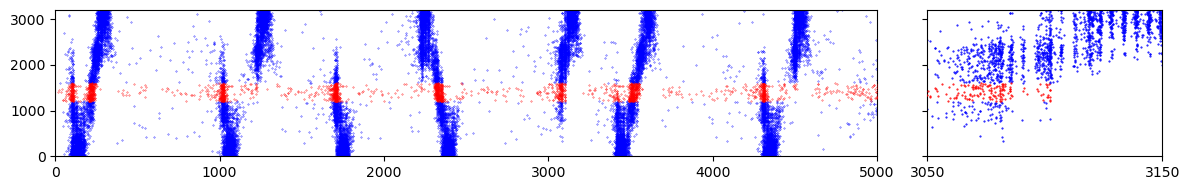

In [91]:
fig,axs = plt.subplots(1,2,figsize=(12,2), width_ratios=[3.5, 1], sharey=True)

spike_t    = spike_times_CA3_PC           # ms
spike_nids = spiking_neurons_CA3_PC.astype(int)
states_v   = np.array([wu_state_from_nid(n) for n in spike_nids])

roll_out_time = [3050,3150]
for s in range(num_state_total):
    mask = states_v == s
    if mask.any():
        axs[0].scatter(
            spike_t[mask], spike_nids[mask],
            s=0.3, c=wu_state_color(s), rasterized=True, marker='.',
            zorder=3 if s == CUE_STATE else
                    2 if s > CUE_STATE else 1,
                    )
        axs[1].scatter(
            spike_t[mask], spike_nids[mask],
            s=1.0, c=wu_state_color(s), rasterized=True, marker='.',
            zorder=3 if s == CUE_STATE else
                    2 if s > CUE_STATE else 1,
                    )
axs[0].set_xlim(0, 5000); axs[1].set_xlim(roll_out_time)
axs[0].set_ylim(0, num_CA3_neurons); axs[1].set_ylim(0, num_CA3_neurons)
axs[1].set_xticks(roll_out_time)
fig.tight_layout()
if save_plot: plt.savefig(os.path.join(plot_path,"Onsite_replay_lap_%d.png"%(load_lap)), dpi=300)
plt.show()

### Fig. 6n, Accessing shock presence information through forward roll-out

In [109]:
window = 100

ff = np.load(os.path.join(data_path,folder_root+str(example_seed),"CA1_replay_lap_%d_pause_%d.npz"%(load_lap, pause_state)))
spk_time = ff["spike_times_CA1_PC"]; spk_neuron = ff["spiking_neurons_CA1_PC"]
del ff

w_CA1_feat = np.load(os.path.join(data_path,foldername,"lap_%d.npz"%load_lap))["w_CA1_feat"]
w_CA1_feat[w_CA1_feat<0] = 0

select_idx = np.where((spk_time>(roll_out_time[0]-window))&(spk_time<roll_out_time[1]))[0]
spk_time = spk_time[select_idx]
spk_neuron = spk_neuron[select_idx]

pred = np.zeros(roll_out_time[1]-roll_out_time[0])
for tt in range(roll_out_time[1]-roll_out_time[0]):
    select_idx = np.where((spk_time>(tt+roll_out_time[0]-window))&(spk_time<(tt+roll_out_time[0])))[0]
    pred[tt] = np.sum(w_CA1_feat[spk_neuron[select_idx],1])*(1000//window)

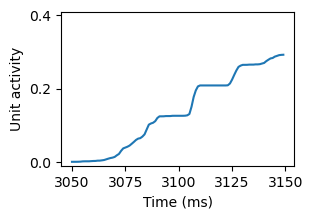

Menn Kendell, shock prediction unit activity during the rollout: 
p=8.403e-47  z=14.3664  tau=0.9743


In [118]:
plt.figure(figsize=(3, 2))
plt.plot(np.arange(roll_out_time[0],roll_out_time[1]),pred)
plt.ylim([-0.01,0.41]); plt.yticks([0,0.2,0.4]); plt.xlabel("Time (ms)"); plt.ylabel("Unit activity")

plt.savefig(os.path.join(plot_path,"rollout_prediction.svg"), format='svg')
plt.show()

label = 'Menn Kendell, shock prediction unit activity during the rollout'

import pymannkendall as mk
mk_results = mk.original_test(pred)

# mk_results.p underflows to 0 for large |z|: pymannkendall computes
# p = 2*(1 - norm.cdf(abs(z))), which loses all precision to catastrophic
# cancellation once norm.cdf(abs(z)) rounds to 1.0. Recompute from z using
# the survival function, which remains accurate for arbitrarily small p.
p_precise = 2 * stats.norm.sf(abs(mk_results[3]))

print(f'{label}: \np={p_precise:.4g}  z={mk_results[3]:.4f}  '
    f'tau={mk_results[4]:.4f}')